# State space

A state-space model separates a hidden *state* that evolves over time from the *observations* it emits. It is the general framework underlying ARIMA, ETS, and Kalman filtering; `StateSpaceGenerator` lets you specify the transition and observation dynamics directly to build custom linear systems.

::: {.callout-note}
## The model

A latent state evolves by a linear transition with process noise, and is mapped to the observed series by an observation equation with measurement noise. Choosing these dynamics reproduces local-level, local-trend, and other structural time-series models.
:::

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import StateSpaceGenerator

## 1. Basic Local Level Model (Random Walk with Noise)

The simplest state space model: a hidden random walk observed with measurement noise.

In [ ]:
local_level_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "state_dim": 1,
    "obs_dim": 1,
    "seed": 42,
}
local_level_gen = StateSpaceGenerator(engine="polars", **local_level_params)
local_level_df = local_level_gen.generate(n_series=1)
print(f"Generated {len(local_level_df)} observations from local level model")
print(
    f"Statistics: Mean={local_level_df['y'].mean():.4f}, "
    f"Std={local_level_df['y'].std():.4f}"
)
local_level_df.head(10)

Generated 200 observations from local level model
Statistics: Mean=-0.0235, Std=0.4556


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-1.477252
"""0""",2000-01-02 00:00:00,0.466308
"""0""",2000-01-03 00:00:00,-0.351479
"""0""",2000-01-04 00:00:00,-0.460238
"""0""",2000-01-05 00:00:00,-0.088038
"""0""",2000-01-06 00:00:00,-0.199117
"""0""",2000-01-07 00:00:00,0.23307
"""0""",2000-01-08 00:00:00,-0.331227
"""0""",2000-01-09 00:00:00,-0.634035


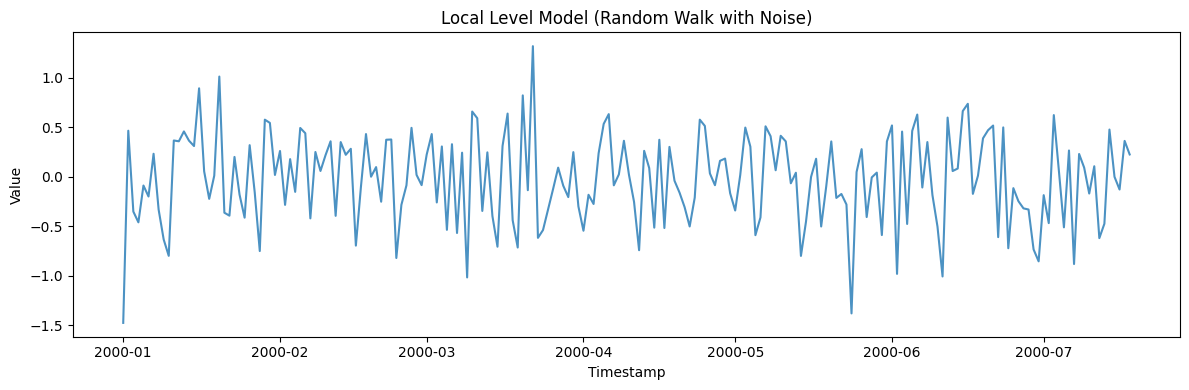

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(local_level_df["ds"].to_list(), local_level_df["y"].to_list(), alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Local Level Model (Random Walk with Noise)")
plt.tight_layout()
plt.show()

## 2. 2D State Space Model (Level + Trend)

A two-dimensional state captures both the level and its trend (rate of change).

In [ ]:
two_dim_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "state_dim": 2,
    "obs_dim": 1,
    "seed": 42,
}
two_dim_gen = StateSpaceGenerator(engine="polars", **two_dim_params)
two_dim_df = two_dim_gen.generate(n_series=1)
print(f"Generated {len(two_dim_df)} observations from 2D state space model")
print(
    f"Statistics: Mean={two_dim_df['y'].mean():.4f}, "
    f"Std={two_dim_df['y'].std():.4f}"
)
two_dim_df.head(10)

Generated 200 observations from 2D state space model
Statistics: Mean=-0.0315, Std=0.4513


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,2.035213
"""0""",2000-01-02 00:00:00,0.342724
"""0""",2000-01-03 00:00:00,-0.130302
"""0""",2000-01-04 00:00:00,-0.445831
"""0""",2000-01-05 00:00:00,0.159239
"""0""",2000-01-06 00:00:00,-0.206335
"""0""",2000-01-07 00:00:00,0.401635
"""0""",2000-01-08 00:00:00,-0.350341
"""0""",2000-01-09 00:00:00,0.077724


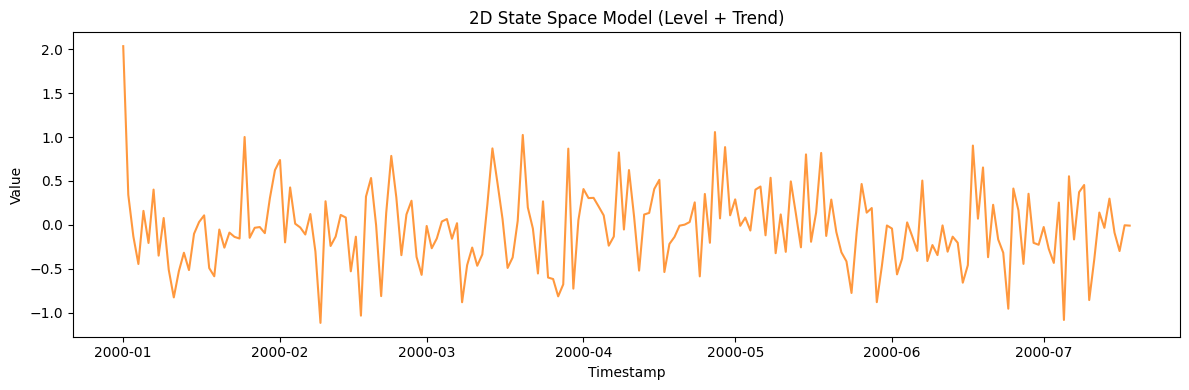

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(two_dim_df["ds"].to_list(), two_dim_df["y"].to_list(), alpha=0.8, color="C1")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("2D State Space Model (Level + Trend)")
plt.tight_layout()
plt.show()

## 3. Custom Transition Matrix (AR-like Behavior)

Specify a custom state transition matrix to create AR-like dynamics in the hidden state.

In [ ]:
transition_matrix = np.array([[0.9, 0.1], [0.0, 0.8]])
custom_transition_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "state_dim": 2,
    "obs_dim": 1,
    "transition_matrix": transition_matrix.tolist(),
    "seed": 42,
}
custom_transition_gen = StateSpaceGenerator(engine="polars", **custom_transition_params)
custom_transition_df = custom_transition_gen.generate(n_series=1)
print(f"Generated {len(custom_transition_df)} observations with custom transition matrix")
print(
    f"Statistics: Mean={custom_transition_df['y'].mean():.4f}, "
    f"Std={custom_transition_df['y'].std():.4f}"
)
custom_transition_df.head(10)

Generated 200 observations with custom transition matrix
Statistics: Mean=0.2258, Std=0.7764


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-1.099579
"""0""",2000-01-02 00:00:00,-1.454542
"""0""",2000-01-03 00:00:00,-0.964621
"""0""",2000-01-04 00:00:00,-1.002322
"""0""",2000-01-05 00:00:00,-1.355461
"""0""",2000-01-06 00:00:00,-0.768567
"""0""",2000-01-07 00:00:00,-1.013438
"""0""",2000-01-08 00:00:00,-0.786117
"""0""",2000-01-09 00:00:00,0.361217


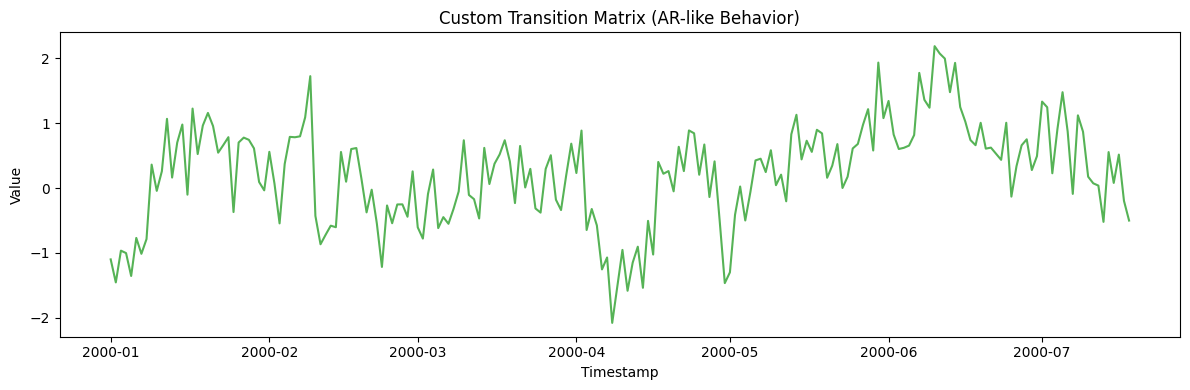

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(custom_transition_df["ds"].to_list(), custom_transition_df["y"].to_list(), alpha=0.8, color="C2")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Custom Transition Matrix (AR-like Behavior)")
plt.tight_layout()
plt.show()

## 4. Custom Observation Matrix (Weighted State Observation)

Observe a weighted combination of the hidden states.

In [ ]:
observation_matrix = np.array([[1.0, 0.5]])
custom_obs_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "state_dim": 2,
    "obs_dim": 1,
    "observation_matrix": observation_matrix.tolist(),
    "seed": 42,
}
custom_obs_gen = StateSpaceGenerator(engine="polars", **custom_obs_params)
custom_obs_df = custom_obs_gen.generate(n_series=1)
print(f"Generated {len(custom_obs_df)} observations with custom observation matrix")
print(
    f"Statistics: Mean={custom_obs_df['y'].mean():.4f}, "
    f"Std={custom_obs_df['y'].std():.4f}"
)
custom_obs_df.head(10)

Generated 200 observations with custom observation matrix
Statistics: Mean=-0.0163, Std=0.4940


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,2.24795
"""0""",2000-01-02 00:00:00,0.496252
"""0""",2000-01-03 00:00:00,0.135206
"""0""",2000-01-04 00:00:00,-0.172047
"""0""",2000-01-05 00:00:00,0.132115
"""0""",2000-01-06 00:00:00,-0.300323
"""0""",2000-01-07 00:00:00,0.495517
"""0""",2000-01-08 00:00:00,-0.444273
"""0""",2000-01-09 00:00:00,-0.004085


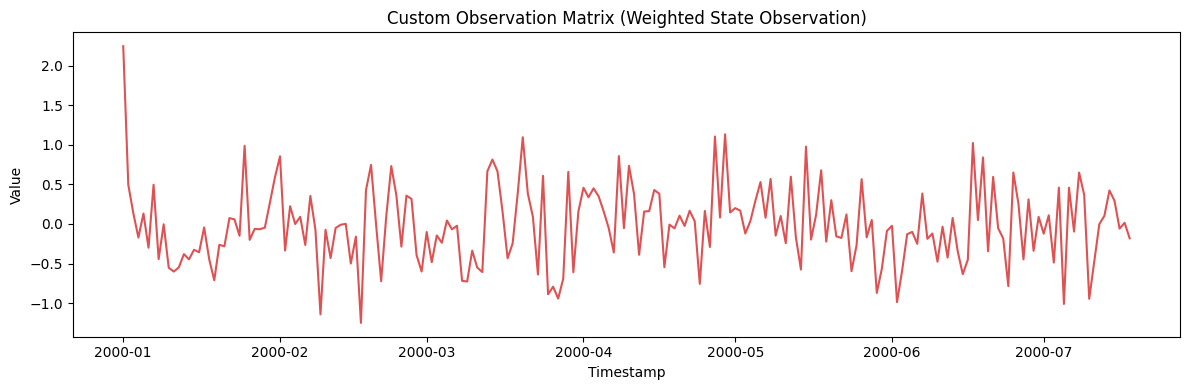

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(custom_obs_df["ds"].to_list(), custom_obs_df["y"].to_list(), alpha=0.8, color="C3")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Custom Observation Matrix (Weighted State Observation)")
plt.tight_layout()
plt.show()

## 5. High Process Noise (Volatile State Evolution)

Increase the process noise covariance to create more volatile hidden state dynamics.

In [ ]:
high_process_noise = np.array([[5.0, 0.0], [0.0, 5.0]])
high_noise_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "state_dim": 2,
    "obs_dim": 1,
    "state_covariance": high_process_noise.tolist(),
    "seed": 42,
}
high_noise_gen = StateSpaceGenerator(engine="polars", **high_noise_params)
high_noise_df = high_noise_gen.generate(n_series=1)
print(f"Generated {len(high_noise_df)} observations with high process noise")
print(
    f"Statistics: Mean={high_noise_df['y'].mean():.4f}, "
    f"Std={high_noise_df['y'].std():.4f}"
)
high_noise_df.head(10)

Generated 200 observations with high process noise
Statistics: Mean=-0.1518, Std=2.2105


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,2.035213
"""0""",2000-01-02 00:00:00,2.980453
"""0""",2000-01-03 00:00:00,2.307622
"""0""",2000-01-04 00:00:00,-1.815772
"""0""",2000-01-05 00:00:00,1.32836
"""0""",2000-01-06 00:00:00,-2.890637
"""0""",2000-01-07 00:00:00,-0.526938
"""0""",2000-01-08 00:00:00,-2.710086
"""0""",2000-01-09 00:00:00,-1.37662


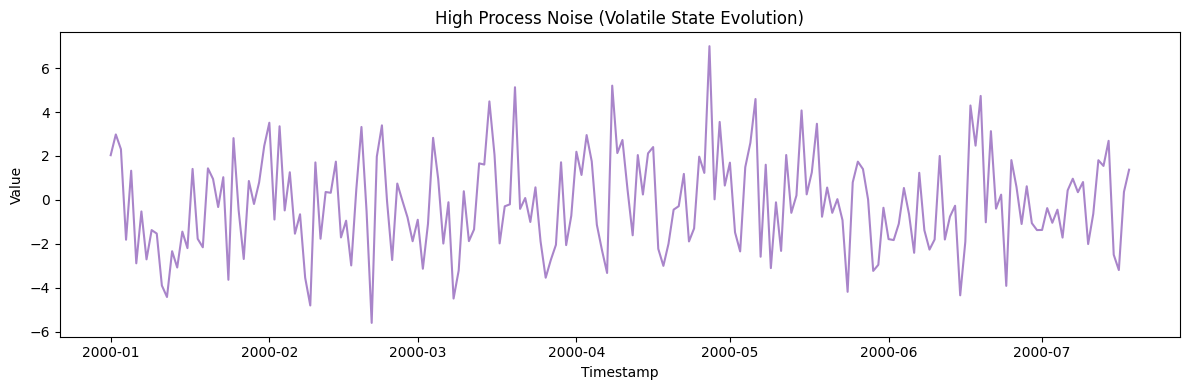

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(high_noise_df["ds"].to_list(), high_noise_df["y"].to_list(), alpha=0.8, color="C4")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("High Process Noise (Volatile State Evolution)")
plt.tight_layout()
plt.show()

## 6. High Observation Noise (Noisy Measurements)

Increase the observation noise to simulate noisy measurement conditions.

In [ ]:
high_obs_noise = np.array([[10.0]])
noisy_obs_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "state_dim": 2,
    "obs_dim": 1,
    "obs_covariance": high_obs_noise.tolist(),
    "seed": 42,
}
noisy_obs_gen = StateSpaceGenerator(engine="polars", **noisy_obs_params)
noisy_obs_df = noisy_obs_gen.generate(n_series=1)
print(f"Generated {len(noisy_obs_df)} observations with high observation noise")
print(
    f"Statistics: Mean={noisy_obs_df['y'].mean():.4f}, "
    f"Std={noisy_obs_df['y'].std():.4f}"
)
noisy_obs_df.head(10)

Generated 200 observations with high observation noise
Statistics: Mean=-0.2227, Std=2.9604


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,5.679936
"""0""",2000-01-02 00:00:00,-2.754326
"""0""",2000-01-03 00:00:00,-5.158032
"""0""",2000-01-04 00:00:00,-2.433461
"""0""",2000-01-05 00:00:00,-0.135867
"""0""",2000-01-06 00:00:00,1.917522
"""0""",2000-01-07 00:00:00,5.393208
"""0""",2000-01-08 00:00:00,-0.005179
"""0""",2000-01-09 00:00:00,2.933222


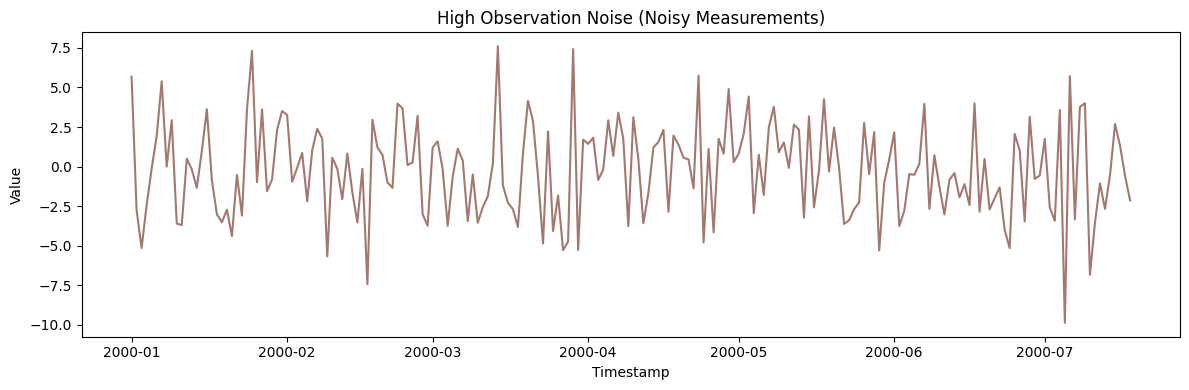

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(noisy_obs_df["ds"].to_list(), noisy_obs_df["y"].to_list(), alpha=0.8, color="C5")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("High Observation Noise (Noisy Measurements)")
plt.tight_layout()
plt.show()

## 7. Generate with Hidden States

Return both observations and hidden states to inspect the latent dynamics.

In [ ]:
with_states_params = {
    "min_length": 100,
    "max_length": 100,
    "freq": "D",
    "state_dim": 2,
    "obs_dim": 1,
    "seed": 42,
}
with_states_gen = StateSpaceGenerator(engine="polars", **with_states_params)
obs_df, states_df = with_states_gen.generate_with_states(n_series=1)
print(f"Generated observations and hidden states")
print(
    f"Observation Statistics: Mean={obs_df['y'].mean():.4f}, "
    f"Std={obs_df['y'].std():.4f}"
)
print("\nObservations:")
print(obs_df.head(10))
print("\nHidden States:")
print(states_df.head(10))

Generated observations and hidden states
Observation Statistics: Mean=-0.0286, Std=0.4412

Observations:
shape: (10, 3)
┌───────────┬─────────────────────┬───────────┐
│ unique_id ┆ ds                  ┆ y         │
│ ---       ┆ ---                 ┆ ---       │
│ cat       ┆ datetime[ns]        ┆ f64       │
╞═══════════╪═════════════════════╪═══════════╡
│ 0         ┆ 2000-01-01 00:00:00 ┆ -1.910609 │
│ 0         ┆ 2000-01-02 00:00:00 ┆ -0.642705 │
│ 0         ┆ 2000-01-03 00:00:00 ┆ 0.258913  │
│ 0         ┆ 2000-01-04 00:00:00 ┆ 0.120297  │
│ 0         ┆ 2000-01-05 00:00:00 ┆ 0.451117  │
│ 0         ┆ 2000-01-06 00:00:00 ┆ -0.195514 │
│ 0         ┆ 2000-01-07 00:00:00 ┆ 0.256028  │
│ 0         ┆ 2000-01-08 00:00:00 ┆ 0.070385  │
│ 0         ┆ 2000-01-09 00:00:00 ┆ 0.791294  │
│ 0         ┆ 2000-01-10 00:00:00 ┆ -0.372822 │
└───────────┴─────────────────────┴───────────┘

Hidden States:
shape: (10, 4)
┌───────────┬─────────────────────┬───────────┬───────────┐
│ unique_id ┆ ds     

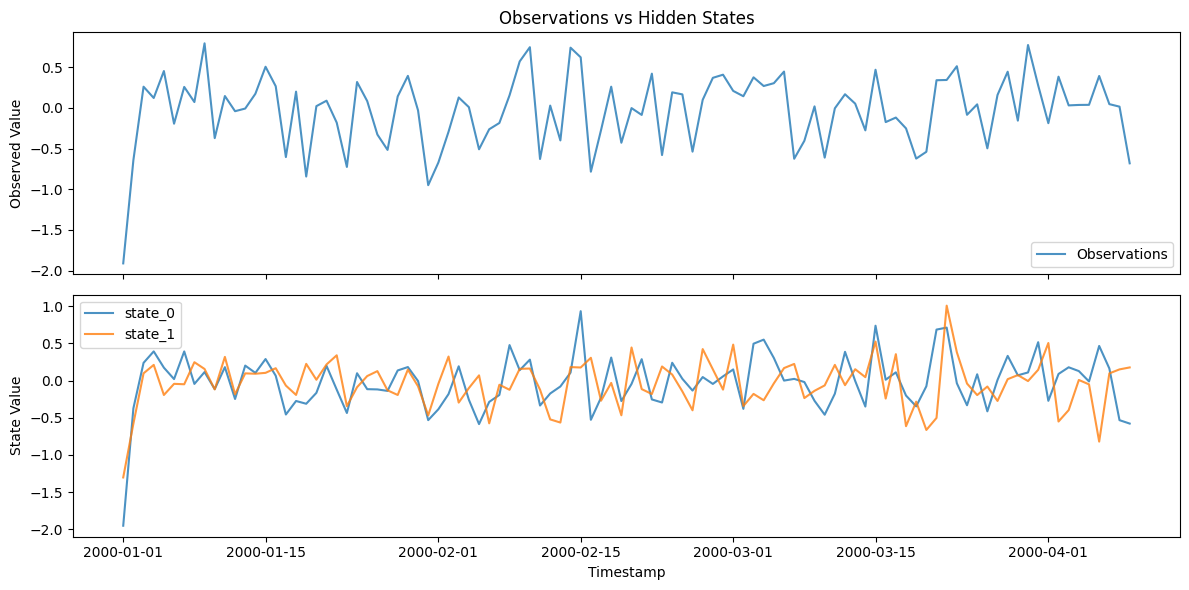

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(obs_df["ds"].to_list(), obs_df["y"].to_list(), alpha=0.8, label="Observations")
axes[0].set_ylabel("Observed Value")
axes[0].set_title("Observations vs Hidden States")
axes[0].legend()

state_cols = [c for c in states_df.columns if c.startswith("state_")]
for col in state_cols:
    axes[1].plot(states_df["ds"].to_list(), states_df[col].to_list(), alpha=0.8, label=col)
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("State Value")
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Multiple State Space Series

Generate multiple independent state space series.

In [ ]:
multi_params = {
    "min_length": 150,
    "max_length": 150,
    "freq": "D",
    "state_dim": 2,
    "obs_dim": 1,
    "seed": 42,
}
multi_gen = StateSpaceGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=3)
print(f"Generated 3 series with {len(multi_df)} total observations")
print(
    f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, "
    f"Std={multi_df['y'].std():.4f}"
)

multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 3 series with 450 total observations
Overall Statistics: Mean=-0.0026, Std=0.4818


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,2.035213
"""0""",2000-01-02 00:00:00,0.342724
"""0""",2000-01-03 00:00:00,-0.130302
"""0""",2000-01-04 00:00:00,-0.445831
"""0""",2000-01-05 00:00:00,0.159239
"""0""",2000-01-06 00:00:00,-0.206335
"""0""",2000-01-07 00:00:00,0.401635
"""0""",2000-01-08 00:00:00,-0.350341
"""0""",2000-01-09 00:00:00,0.077724


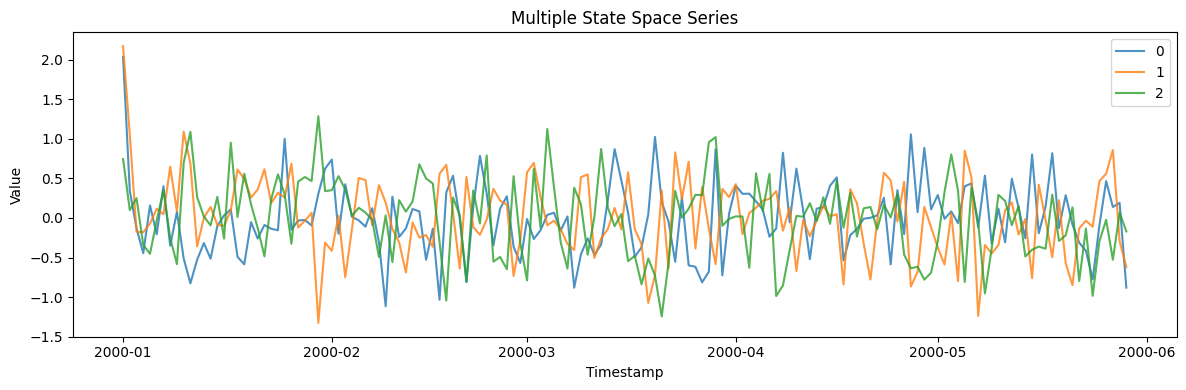

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple State Space Series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [SARIMA](../statistical/sarima) and [ETS](../statistical/ets) — specific state-space families.
- [Chaotic system](../stochastic/chaotic_system) — deterministic nonlinear dynamics.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::